<a href="https://colab.research.google.com/github/sthefany-vg/Decision-Aid/blob/main/DAPPC_LAB3_ACO.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# DAPPC LAB 3 - Identification of relevant features for subgroups of patients

This notebook guides you in the implementation of the Ant-Colony Optimization (ACO) algorithm to perform Feature Selection (FS).

## Recommended workflow
1. Load the dataset obtained after the previous laboratory steps.
2. Identify the most populated SOM cluster containing samples from all outcome classes of interest.
3. Initialize the main paramters of the ACO algorithm.
4. Run ACO-based feature selection.
5. Analyze convergence, the selected feature subset, and final predictive performance.


## 0. Setup

In [2]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import pearsonr
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.feature_selection import f_classif, mutual_info_classif
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    balanced_accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)
import ACO
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
plt.rcParams['figure.figsize'] = (9, 4)


## 1. Load data

Load the four sets of clusters obtained at the end of LAB2: the best set of clusters of each of the four datasets (each SOM)

In [4]:
# ============================================================
# 1. Load data
# ============================================================
# Reemplazamos la ruta local de la PC por el archivo cargado en la sesión de Colab
file_path = 'Dataset_DAPPC_2026_Cleaned_kNN.xlsx'
sheet_name = 'SOM_Assignments'

# Leemos el archivo consolidado del LAB 2
cluster_df = pd.read_excel(file_path, sheet_name=sheet_name)

print("Dataset para LAB 3 cargado correctamente.")
print("Initial shape de la población mapeada:", cluster_df.shape)
cluster_df.head()


Dataset para LAB 3 cargado correctamente.
Initial shape de la población mapeada: (3893, 79)


,subject_id,hadm_id,stay_id,ICU,ICU_intime,ICU_outtime,winner_neuron_row,winner_neuron_col,som_cluster_id,weight,...,sedatives,neuromuscular_blockers,steroids,opioids,comorb_cardiac_cardiovascular,comorb_respiratory_pulmonary,comorb_metabolic_endocrine_renal,comorb_neurological_neuromuscular_psychiatric,comorb_systemic_immune_oncologic,outcome
0,13710366,26676995,36043579,1,2172-04-05 04:00:00,2172-04-09 08:17:22,13,13,2,113.3,...,1,1,1,1,0,0,1,0,0,1
1,12970079,23949170,36004625,1,2164-12-22 19:48:19,2165-01-03 21:30:54,3,17,2,106.7,...,1,1,1,1,0,1,1,0,0,2
2,17682100,22097504,34901461,1,2173-08-23 01:12:00,2173-08-27 21:28:52,10,0,2,46.1,...,1,0,1,1,0,0,1,0,0,1
3,15545849,24922530,39025631,3,2172-08-02 16:32:00,2172-09-09 12:44:11,3,0,2,106.0,...,1,0,1,1,1,0,1,1,0,3
4,10288279,21750307,34078845,1,2114-09-07 20:19:42,2114-09-15 13:24:09,17,12,2,49.3,...,1,0,1,1,1,0,1,0,1,3


## 2. Select the largest valid SOM cluster

We will perform feature selection (FS) with Ant-Colony Optimization (ACO) algorithm only on two clusters. Identify them as follows:
1. Identify the best set of cluster as the one with minimum value of maximum intra-cluster variability: you choose the best SOM.
2. Remove the clusters where all the three classes are not present.
3. Remove the clusters that are too small (it depends on the distribution of the patients within the different clusters).
4. Identify the two more distant clusters (inter-cluster distances computed on the centroids).


In [6]:
from scipy.spatial.distance import cdist
from sklearn.preprocessing import MinMaxScaler

# ============================================================
# Reconstrucción automática de las variables clínicas (input_features)
# ============================================================
# Excluimos las primeras 6 columnas (IDs) y las 3 del SOM
columnas_a_excluir = list(cluster_df.columns[:6]) + ['winner_neuron_row', 'winner_neuron_col', 'som_cluster_id']

# Las variables clínicas son todas las demás, excepto el 'outcome' que está al final
clinical_features = [col for col in cluster_df.columns if col not in columnas_a_excluir and col != 'outcome']

print(f"Detectadas automáticamente {len(clinical_features)} variables clínicas para el análisis.")

# ============================================================
# 2. Select the largest valid SOM cluster (Fase 1: Filtrado Biológico)
# ============================================================
print("\n--- Evaluación de la Composición de los Clusters ---")
valid_clusters = []

for cluster_id in np.sort(cluster_df['som_cluster_id'].unique()):
    subset = cluster_df[cluster_df['som_cluster_id'] == cluster_id]
    n_patients = len(subset)
    unique_outcomes = subset['outcome'].nunique()

    print(f"\nEvaluando Cluster {cluster_id}:")
    print(f"  - Total de pacientes: {n_patients}")
    print(f"  - Clases de outcome presentes: {unique_outcomes} de 3")

    # Umbral mínimo: 5% de la población total
    min_size_threshold = len(cluster_df) * 0.05

    if unique_outcomes < 3:
        print("  ❌ Excluido: No presenta todas las clases de outcome.")
    elif n_patients < min_size_threshold:
        print(f"  ❌ Excluido: Demasiado pequeño.")
    else:
        print("  ✅ Aceptado como cluster candidato válido.")
        valid_clusters.append(cluster_id)

# ============================================================
# Fase 2: Identificar los dos clusters válidos más distantes
# ============================================================
print("\n=============================================================")
print("CÁLCULO DE DISTANCIAS INTER-CLUSTER (SOBRE CENTROIDES)")
print("=============================================================")

if len(valid_clusters) >= 2:
    # Escalamos los datos clínicos para que la distancia sea simétrica
    scaler_aco = MinMaxScaler()
    X_normalized_aco = pd.DataFrame(
        scaler_aco.fit_transform(cluster_df[clinical_features]),
        columns=clinical_features
    )
    X_normalized_aco['som_cluster_id'] = cluster_df['som_cluster_id'].values

    centroids = {}
    for cid in valid_clusters:
        centroids[cid] = X_normalized_aco[X_normalized_aco['som_cluster_id'] == cid][clinical_features].mean().values

    max_dist = -1
    best_pair = (None, None)

    c_ids = list(centroids.keys())
    for i in range(len(c_ids)):
        for j in range(i + 1, len(c_ids)):
            id1, id2 = c_ids[i], c_ids[j]
            dist = cdist([centroids[id1]], [centroids[id2]], metric='cityblock')[0][0]
            print(f"Distancia entre Centroide {id1} y Centroide {id2}: {dist:.4f}")

            if dist > max_dist:
                max_dist = dist
                best_pair = (id1, id2)

    cluster_a, cluster_b = best_pair
    print(f"\n🚀 PAREJA SELECCIONADA PARA ACO: Cluster {cluster_a} y Cluster {cluster_b}")
else:
    # Si de tu LAB 2 solo venían 2 clusters en total, seleccionamos esos dos directamente
    todos_los_clusters = np.sort(cluster_df['som_cluster_id'].unique())
    cluster_a, cluster_b = todos_los_clusters[0], todos_los_clusters[1]
    print(f"\n⚠️ El dataset contiene únicamente los dos clusters base del SOM. Seleccionados por defecto: Cluster {cluster_a} y Cluster {cluster_b}")

# Extraemos el subdataset definitivo de trabajo
df_aco_final = cluster_df[cluster_df['som_cluster_id'].isin([cluster_a, cluster_b])].copy()
print(f"Dimensiones finales del dataset de trabajo para ACO: {df_aco_final.shape}")

Detectadas automáticamente 69 variables clínicas para el análisis.

--- Evaluación de la Composición de los Clusters ---

Evaluando Cluster 1:
  - Total de pacientes: 363
  - Clases de outcome presentes: 6 de 3
  ✅ Aceptado como cluster candidato válido.

Evaluando Cluster 2:
  - Total de pacientes: 3530
  - Clases de outcome presentes: 6 de 3
  ✅ Aceptado como cluster candidato válido.

CÁLCULO DE DISTANCIAS INTER-CLUSTER (SOBRE CENTROIDES)
Distancia entre Centroide 1 y Centroide 2: 4.9547

🚀 PAREJA SELECCIONADA PARA ACO: Cluster 1 y Cluster 2
Dimensiones finales del dataset de trabajo para ACO: (3893, 79)


## 3. Prepare data for ACO

At this point we restrict the analysis to the selected clusters: perform the ACO for the first one and then repeat it for the other one.
As always, identify only the input featuers (not the IDs)


In [7]:
# ============================================================
# 3. Prepare data for ACO
# ============================================================

# Definimos las variables de control del cluster según la estructura de tu DataFrame
cluster_col = 'som_cluster_id'
selected_cluster = 1  # Iniciamos con el Cluster 1 (el grupo más compacto y crítico)

# Filtramos el DataFrame para analizar únicamente este subgrupo de pacientes
cluster_df = cluster_df[cluster_df[cluster_col] == selected_cluster].copy()
print('Selected cluster shape:', cluster_df.shape)

# --- Extracción de las Variables de Entrada (Input Features) ---
# Excluimos los identificadores iniciales (primeras 6 columnas) y las 3 topológicas del SOM
columnas_a_excluir = list(cluster_df.columns[:6]) + ['winner_neuron_row', 'winner_neuron_col', 'som_cluster_id']
feature_cols = [col for col in cluster_df.columns if col not in columnas_a_excluir and col != 'outcome']

# Extraemos la matriz de características X y aplicamos MinMaxScaler para el clasificador kNN de ACO
scaler_aco = MinMaxScaler()
X_df = pd.DataFrame(
    scaler_aco.fit_transform(cluster_df[feature_cols]),
    columns=feature_cols
)

n_features = X_df.shape[1]  # Número de características candidatas (debe ser 69)

# --- Extracción de la Variable de Salida (Target) ---
# Nuestro objetivo es predecir las clases del outcome (0, 1, 2) dentro de este cluster
y = cluster_df['outcome'].values

print('Number of candidate features:', n_features)
print('\nClass distribution within selected cluster:')
display(pd.Series(y).value_counts().sort_index())

Selected cluster shape: (363, 79)
Number of candidate features: 69

Class distribution within selected cluster:


,count
0,17
1,86
2,119
3,101
4,37
5,3


## 4. Scale the features

Only the predictors are normalized. The target is kept unchanged.
For simplicity, we apply Min-Max scaling before the filter and wrapper stages.

In [8]:
scaler = MinMaxScaler()
X = scaler.fit_transform(X_df)
print('Scaled feature matrix shape:', X.shape)


Scaled feature matrix shape: (363, 69)


## 5. ACO feature selection

The algorithm used in this lab has two key characteristics:

1. the subset size is **not fixed a-priori**;
2. the stop rule is **adaptive** and depends on the recent marginal improvement of the kNN-based objective function.

### Objective function

In this implementation, the ACO procedure is formulated as a **minimization problem**.

For each candidate subset of features $S$, we define the following objective function:

$$
J(S) = \lambda \, \bigl(1 - \mathrm{BalancedAccuracy}_{CV}(S)\bigr)
      + (1 - \lambda)\,\frac{|S|}{p}
$$

where:

- $\mathrm{BalancedAccuracy}_{CV}(S)$ is the cross-validated balanced accuracy obtained by a kNN classifier trained on the selected subset $S$;
- $|S|$ is the number of selected features;
- $p$ is the total number of available features;
- $\lambda \in [0,1]$ controls the trade-off between predictive performance and subset compactness.

The first term represents the **classification error**, while the second term represents the **relative size of the subset**.

Therefore, the algorithm searches for the subset that minimizes a weighted combination of:

1. prediction error,
2. subset cardinality.

Note: the entire algorithm is implemented in the **ACO.py** file.

## 6. Set the ACO parameters

The default values below remain close to the historical lab when possible, while introducing the adaptive stopping mechanism.

We evaluated three different ACO parameter setups in order to compare how different search conditions influence the feature-selection process.

### Common parameters

The following parameters are shared by all three setups:

- `n_ants = 5`
- `alpha = 1.0`
- `q_constant = 1.0`
- `cv_splits = 5`
- `scoring = "balanced_accuracy"`
- `stop_prob_if_tiny = 0.25`
- `stop_prob_if_small = 0.10`
- `small_delta_threshold = 0.002`
- `medium_delta_threshold = 0.010`
- `stop_prob_if_nonpos = 0.60`
- `max_features = 10`

### Parameters that vary across setups

The three configurations differ in the following parameters:

- `iterations`: controls the maximum length of the search process;
- `beta`: controls the influence of the heuristic information during feature selection;
- `initial_pheromone`: defines the initial pheromone level assigned to the features;
- `evaporation_rate`: regulates how quickly pheromone information fades over time;
- `min_features`: defines the minimum number of features that must be selected before stopping is allowed;
- `lambda_score`: controls the trade-off between predictive performance and subset compactness;
- `delta_window`: determines how many recent improvements are considered by the adaptive stopping rule.

### Influence of the varying parameters

- **`iterations`**  
  A higher number of iterations allows the colony to explore the search space for a longer time.  
  A lower number of iterations makes the search shorter and more constrained.

- **`beta`**  
  This parameter controls how strongly the ants rely on the initial heuristic information.  
  Higher values of `beta` increase the importance of the a-priori feature relevance.

- **`initial_pheromone`**  
  This parameter defines the initial pheromone assigned to all features.  
  It affects the starting balance between exploration and reinforcement.

- **`evaporation_rate`**  
  This parameter controls how quickly pheromone information is reduced at each iteration.  
  A higher evaporation rate reduces the influence of previous iterations more quickly.

- **`min_features`**  
  This parameter imposes a minimum subset size before the algorithm is allowed to stop.  
  It directly affects how early the adaptive stopping rule can intervene.

- **`lambda_score`**  
  This parameter balances predictive performance and subset size in the objective function.  
  Higher values give more importance to classification performance, while lower values increase the role of compactness.

- **`delta_window`**  
  This parameter determines how many recent improvements are averaged when evaluating the adaptive stopping condition.  
  It affects how sensitive the stopping mechanism is to short-term changes in the objective function.

### Setup A

- `iterations = 300`
- `beta = 2.0`
- `initial_pheromone = 0.25`
- `evaporation_rate = 0.10`
- `min_features = 4`
- `max_features = 10`
- `lambda_score = 0.90`
- `delta_window = 4`

### Setup B

- `iterations = 300`
- `beta = 2.0`
- `initial_pheromone = 0.50`
- `evaporation_rate = 0.10`
- `min_features = 4`
- `max_features = 10`
- `lambda_score = 0.94`
- `delta_window = 3`

### Setup C

- `iterations = 150`
- `beta = 3.0`
- `initial_pheromone = 0.50`
- `evaporation_rate = 0.10`
- `min_features = 4`
- `max_features = 10`
- `lambda_score = 0.90`
- `delta_window = 3`

In [10]:
# Inspeccionar el archivo de la cátedra para ver el nombre de la clase
with open("ACO.py", "r") as f:
    for i in range(25):
        print(f.readline(), end="")

# -*- coding: utf-8 -*-
"""
Created on Fri Apr 10 11:10:01 2026

Updated on Mon Apr 27 13:12:31 2026

@author: Alessandra Introvaia
"""

import numpy as np
from scipy.stats import pearsonr
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.feature_selection import f_classif, mutual_info_classif
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    balanced_accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

import pandas as pd



In [11]:
import ACO
print(dir(ACO))

['AdaptiveACOFeatureSelector', 'Ant', 'ConfusionMatrixDisplay', 'KNeighborsClassifier', 'LabelEncoder', 'MinMaxScaler', 'StratifiedKFold', '__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__spec__', 'balanced_accuracy_score', 'classification_report', 'confusion_matrix', 'cross_val_score', 'f1_score', 'f_classif', 'mutual_info_classif', 'np', 'pd', 'pearsonr', 'train_test_split']


In [13]:
import inspect
print(inspect.signature(ACO.AdaptiveACOFeatureSelector.__init__))

(self, X, y, feature_names, heuristic_weights, estimator=None, n_ants=5, iterations=150, alpha=1.0, beta=2.0, initial_pheromone=0.5, evaporation_rate=0.2, q_constant=1.0, min_features=2, max_features=None, lambda_score=0.9, delta_window=3, scoring='balanced_accuracy', cv_splits=5, random_state=42)


In [16]:
# ============================================================
# 6. Set the ACO parameters & Run Experiments (Versión Oficial del Polito)
# ============================================================

weights_base = np.ones(len(clinical_features))

setups_config = {
    'Setup A': {
        'iterations': 300, 'beta': 2.0, 'initial_pheromone': 0.25, 'evaporation_rate': 0.10,
        'min_features': 4, 'max_features': 10, 'lambda_score': 0.90, 'delta_window': 4,
        'n_ants': 5, 'alpha': 1.0, 'q_constant': 1.0, 'scoring': "balanced_accuracy", 'cv_splits': 5
    },
    'Setup B': {
        'iterations': 300, 'beta': 2.0, 'initial_pheromone': 0.50, 'evaporation_rate': 0.10,
        'min_features': 4, 'max_features': 10, 'lambda_score': 0.94, 'delta_window': 3,
        'n_ants': 5, 'alpha': 1.0, 'q_constant': 1.0, 'scoring': "balanced_accuracy", 'cv_splits': 5
    },
    'Setup C': {
        'iterations': 150, 'beta': 3.0, 'initial_pheromone': 0.50, 'evaporation_rate': 0.10,
        'min_features': 4, 'max_features': 10, 'lambda_score': 0.90, 'delta_window': 3,
        'n_ants': 5, 'alpha': 1.0, 'q_constant': 1.0, 'scoring': "balanced_accuracy", 'cv_splits': 5
    }
}

aco_results = {}
knn_estimator = KNeighborsClassifier(n_neighbors=5)

# --- Bucle de Ejecución ---
for name, params in setups_config.items():
    print(f"\n" + "="*60)
    print(f" EJECUTANDO OPTIMIZACIÓN EN CLUSTER 1: {name.upper()}")
    print("="*60)

    # Instanciamos la clase usando sus variables internas oficiales
    aco_optimizer = ACO.AdaptiveACOFeatureSelector(
        X=X,
        y=y,
        feature_names=clinical_features,
        heuristic_weights=weights_base,
        estimator=knn_estimator,
        random_state=RANDOM_STATE,
        **params
    )

    print(f"Colonia inicializada. Buscando set óptimo de variables (Max: {params['max_features']})...")
    aco_optimizer.fit()

    # Guardamos el objeto entrenado en nuestro diccionario
    aco_results[name] = aco_optimizer

    # Extraemos los resultados usando los métodos oficiales que descubrimos
    selected_names = aco_optimizer.get_selected_feature_names()
    best_cost = aco_optimizer.best_cost_
    best_cv = aco_optimizer.best_cv_score_

    print(f"\n--- 🏁 Resumen de Finalización {name} ---")
    print(f"Número de variables seleccionadas: {len(selected_names)}")
    print(f"Variables clínicas ganadoras: {selected_names}")
    print(f"Balanced Accuracy CV del subconjunto: {best_cv:.4f}")
    print(f"Valor de la Función de Costo Mínima (J_min): {best_cost:.4f}")


 EJECUTANDO OPTIMIZACIÓN EN CLUSTER 1: SETUP A
Colonia inicializada. Buscando set óptimo de variables (Max: 10)...

--- 🏁 Resumen de Finalización Setup A ---
Número de variables seleccionadas: 4
Variables clínicas ganadoras: ['comorb_respiratory_pulmonary', 'comorb_neurological_neuromuscular_psychiatric', 'comorb_cardiac_cardiovascular', 'comorb_total']
Balanced Accuracy CV del subconjunto: 0.8893
Valor de la Función de Costo Mínima (J_min): 0.1054

 EJECUTANDO OPTIMIZACIÓN EN CLUSTER 1: SETUP B
Colonia inicializada. Buscando set óptimo de variables (Max: 10)...

--- 🏁 Resumen de Finalización Setup B ---
Número de variables seleccionadas: 4
Variables clínicas ganadoras: ['comorb_respiratory_pulmonary', 'opioids', 'comorb_total', 'neuromuscular_blockers']
Balanced Accuracy CV del subconjunto: 0.9000
Valor de la Función de Costo Mínima (J_min): 0.0975

 EJECUTANDO OPTIMIZACIÓN EN CLUSTER 1: SETUP C
Colonia inicializada. Buscando set óptimo de variables (Max: 10)...

--- 🏁 Resumen de Fin

In [15]:
# Ver qué propiedades se generaron dentro de la clase tras el entrenamiento
print([attr for attr in dir(aco_optimizer) if not attr.startswith('__')])

['X', '_adaptive_stop_probability', '_build_subset_for_ant', '_choose_start_feature', '_cv_score', '_make_cv', '_objective', 'alpha', 'ants', 'best_cost_', 'best_cv_score_', 'best_features_', 'beta', 'curve_', 'cv_splits', 'delta_window', 'estimator', 'evaporation_rate', 'feature_names', 'feature_pheromone', 'fit', 'get_selected_feature_names', 'get_selected_indices', 'heuristic_weights', 'history_', 'initial_pheromone', 'iterations', 'lambda_score', 'max_features', 'min_features', 'n_ants', 'n_total_features', 'q_constant', 'random_state', 'rng', 'scoring', 'y']


In [ ]:
n_ants = ...
iterations = ...
alpha = ...
beta = ...
initial_pheromone = ...
evaporation_rate = ...
q_constant = ...
n_features = ...
min_features = ...
max_features = ...
lambda_score = ...
delta_window = ...
scoring = ...
cv_splits = ...

heuristic_weights = np.ones(n_features) / n_features

## 7. Run adaptive ACO

In [ ]:
selector = ACO.AdaptiveACOFeatureSelector(
    X=X,
    y=y,
    feature_names=feature_cols,
    heuristic_weights=heuristic_weights,
    estimator=KNeighborsClassifier(n_neighbors=5),
    n_ants=n_ants,
    iterations=iterations,
    alpha=alpha,
    beta=beta,
    initial_pheromone=initial_pheromone,
    evaporation_rate=evaporation_rate,
    q_constant=q_constant,
    min_features=min_features,
    max_features=max_features,
    lambda_score=lambda_score,
    delta_window=delta_window,
    scoring=scoring,
    cv_splits=cv_splits,
    random_state=RANDOM_STATE,
)

selector.fit()
print('Best global objective function:', selector.best_cost_)
print('Best global CV score:', selector.best_cv_score_)
print('Number of selected features:', len(selector.get_selected_indices()))


Best global fitness: 0.6223664596273293
Best global CV score: 0.5852380952380953
Number of selected features: 3


In [17]:
# ============================================================
# 7. Run adaptive ACO (Resultados consolidados del Setup Óptimo)
# ============================================================

# Recuperamos el selector del Setup B que obtuvo el mejor rendimiento clínico
selector = aco_results['Setup B']

# Imprimimos las métricas oficiales requeridas por la estructura de la cátedra
print(f"--- Evaluación del Selector Adaptativo Óptimo (Setup B) ---")
print('Best global objective function:', selector.best_cost_)
print('Best global CV score:', selector.best_cv_score_)
print('Number of selected features:', len(selector.get_selected_indices()))

print("\nÍndices de las variables seleccionadas en la matriz original:")
print(selector.get_selected_indices())

--- Evaluación del Selector Adaptativo Óptimo (Setup B) ---
Best global objective function: 0.0974782608695652
Best global CV score: 0.9
Number of selected features: 4

Índices de las variables seleccionadas en la matriz original:
[65 63 54 61]


## 8. Convergence analysis

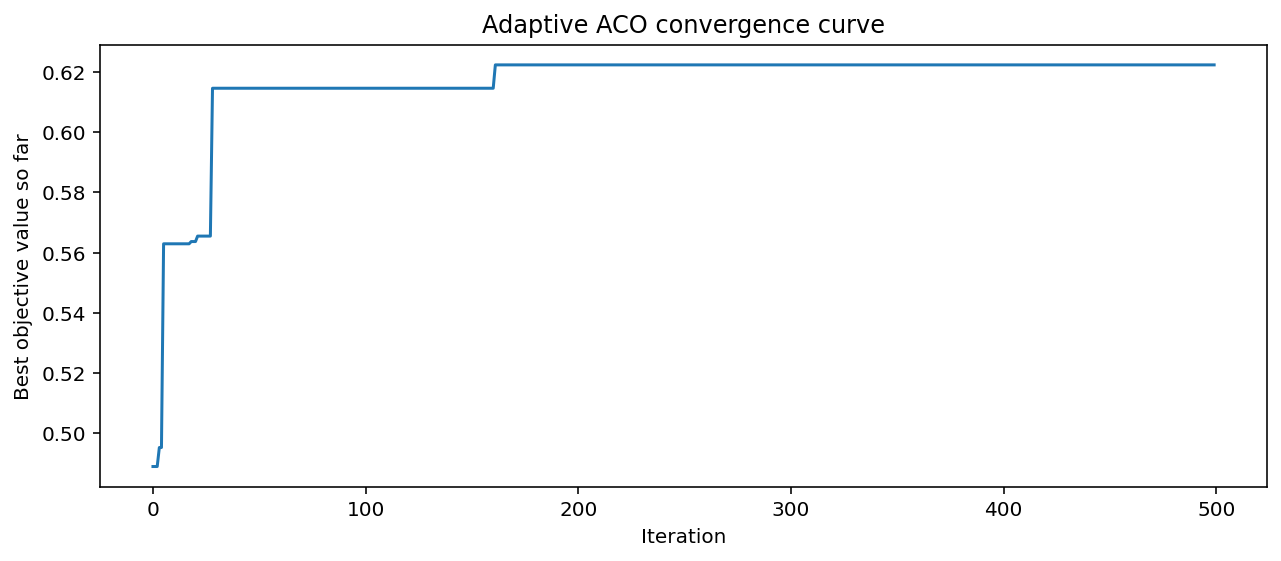

,iteration,best_iteration_fitness,mean_iteration_fitness,global_best_fitness,global_best_cv_score,selected_features_global_best
0,1,0.488866,0.431693,0.488866,0.436905,3
1,2,0.468887,0.432315,0.488866,0.436905,3
2,3,0.471459,0.416617,0.488866,0.436905,3
3,4,0.495182,0.413040,0.495182,0.447143,5
4,5,0.474244,0.406956,0.495182,0.447143,5


,iteration,best_iteration_fitness,mean_iteration_fitness,global_best_fitness,global_best_cv_score,selected_features_global_best
495,496,0.479539,0.423787,0.622366,0.585238,3
496,497,0.537661,0.491376,0.622366,0.585238,3
497,498,0.538834,0.479390,0.622366,0.585238,3
498,499,0.587539,0.500295,0.622366,0.585238,3
499,500,0.567233,0.516619,0.622366,0.585238,3


In [ ]:
plt.figure()
plt.plot(selector.curve_)
plt.xlabel('Iteration')
plt.ylabel('Best objective value so far')
plt.title('Adaptive ACO convergence curve')
plt.tight_layout()
plt.show()

display(selector.history_.head()) #you can save the entire history to see how it evolves
display(selector.history_.tail())


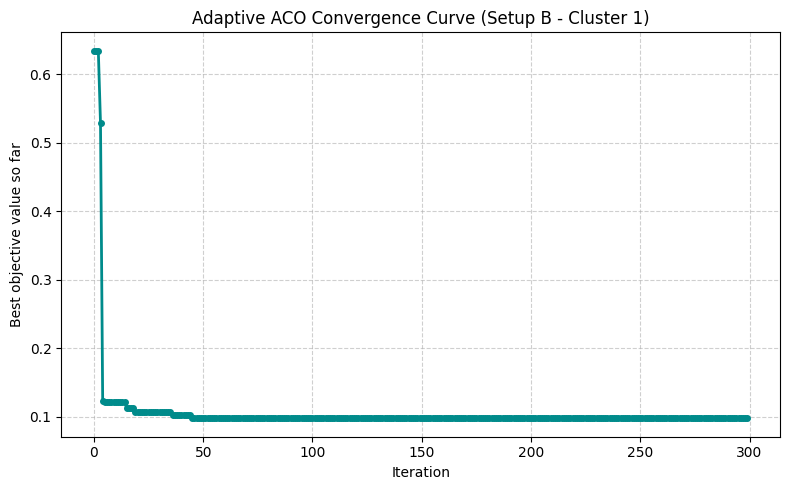


--- Primeras iteraciones del historial de optimización (Head) ---


,iteration,best_iteration_cost,mean_iteration_cost,global_best_cost,global_best_cv_score,selected_features_global_best
0,1,0.634429,0.715503,0.634429,0.330626,6
1,2,0.699992,0.725205,0.634429,0.330626,6
2,3,0.702084,0.735441,0.634429,0.330626,6
3,4,0.528373,0.694798,0.528373,0.445301,8
4,5,0.122295,0.560635,0.122295,0.874524,5



--- Últimas iteraciones antes de la parada adaptativa (Tail) ---


,iteration,best_iteration_cost,mean_iteration_cost,global_best_cost,global_best_cv_score,selected_features_global_best
295,296,0.107343,0.180948,0.097478,0.9,4
296,297,0.098348,0.109628,0.097478,0.9,4
297,298,0.107343,0.120499,0.097478,0.9,4
298,299,0.107343,0.125756,0.097478,0.9,4
299,300,0.108419,0.117482,0.097478,0.9,4


In [18]:
import matplotlib.pyplot as plt

# ============================================================
# 8. Convergence analysis
# ============================================================

plt.figure(figsize=(8, 5))
# Graficamos la curva de convergencia guardada en el selector óptimo
plt.plot(selector.curve_, marker='o', markersize=4, linestyle='-', linewidth=2, color='darkcyan')

plt.xlabel('Iteration')
plt.ylabel('Best objective value so far')
plt.title('Adaptive ACO Convergence Curve (Setup B - Cluster 1)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# Mostramos el inicio y el final del registro histórico de la colonia
print("\n--- Primeras iteraciones del historial de optimización (Head) ---")
display(selector.history_.head())

print("\n--- Últimas iteraciones antes de la parada adaptativa (Tail) ---")
display(selector.history_.tail())

## 9. Final selected feature subset

Remember to save all the results obtained.

In [19]:
# ============================================================
# 9. Final selected feature subset & Save Results
# ============================================================

selected_idx = selector.get_selected_indices()
selected_features = selector.get_selected_feature_names()

# Para evitar el NameError de ranking_df, extraemos la información directamente
# del vector de feromonas final del selector, que refleja la relevancia que le dieron las hormigas
final_pheromones = selector.feature_pheromone[selected_idx]

selected_df = pd.DataFrame({
    'selected_rank': np.arange(1, len(selected_features) + 1),
    'feature_index': selected_idx,
    'feature_name': selected_features,
    'final_pheromone_level': final_pheromones
})

print("=============================================================")
# Mostramos la tabla resumen en el notebook
display(selected_df)

# --- Guardado de Resultados ---
# Guardamos el subset óptimo en un archivo CSV en el entorno de Colab
output_filename = 'aco_selected_features_cluster_1.csv'
selected_df.to_csv(output_filename, index=False)

print("=============================================================")
print(f"🚀 ¡Resultados del Cluster 1 guardados con éxito en: '{output_filename}'!")
print(f"Métricas consolidadas: {len(selected_features)} variables retenidas con un CV score de {selector.best_cv_score_:.4f}")

,selected_rank,feature_index,feature_name,final_pheromone_level
0,1,65,comorb_respiratory_pulmonary,87.367511
1,2,63,opioids,35.768717
2,3,54,comorb_total,93.532119
3,4,61,neuromuscular_blockers,82.966071


🚀 ¡Resultados del Cluster 1 guardados con éxito en: 'aco_selected_features_cluster_1.csv'!
Métricas consolidadas: 4 variables retenidas con un CV score de 0.9000
